In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from datetime import datetime

In [3]:
import arcgis
from arcgis.features import FeatureCollection, FeatureSet
from arcgis.gis import Item
from arcgis.geoprocessing._job import GPJob

In [4]:
from arcgis.gis import GIS
gis = GIS(profile="your_online_profile", verify_cert=False)

In [5]:
from arcgis.features.hydrology import watershed

In [6]:
chennai_lakes = gis.content.get('b98100970c744824b227a5e1ccd113c1')

<Item title:"Chennai Lakes" type:Feature Collection owner:geonuma>
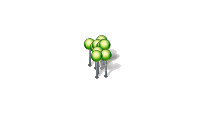

In [7]:
chennai_lakes

In [8]:
lakes_lyr = chennai_lakes.layers[0]

In [9]:
fs = lakes_lyr.query()

In [10]:
lakes_watersheds_test1 = watershed(input_points=fs, snap_distance=10, snap_distance_units='Meters',
              source_database='Finest', generalize=False, return_snapped_points=False)

In [13]:
assert isinstance(lakes_watersheds_test1.watershed_area, FeatureSet)
assert lakes_watersheds_test1.snapped_points is None

In [14]:
lakes_watersheds_test2 = watershed(input_points=fs, snap_distance=10, snap_distance_units='Meters',
              source_database='Finest', generalize=False, return_snapped_points=True)
lakes_watersheds_test2

ToolOutput(watershed_area=<FeatureSet> 11 features, snapped_points=<FeatureSet> 11 features)

In [15]:
assert isinstance(lakes_watersheds_test2.watershed_area, FeatureSet)
assert isinstance(lakes_watersheds_test2.snapped_points, FeatureSet)